In [1]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import joblib

In [2]:
df = pd.read_csv(
    "../data/processed/feature_engineered.csv"
)

df['Date'] = pd.to_datetime(df['Date'])

In [3]:
df = df.sort_values(
    ['State', 'Date']
)

In [4]:
features = [
    'lag_1',
    'lag_7',
    'lag_30',
    'rolling_mean_7',
    'rolling_mean_30',
    'rolling_std_7',
    'day_of_week',
    'month',
    'quarter',
    'week_of_year',
    'year',
    'is_holiday'
]

In [5]:
from xgboost import XGBRegressor

In [6]:
model = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

In [7]:
X = df[features]

y = df['Sales']

model.fit(X, y)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [8]:
joblib.dump(
    model,
    "../models/final_forecasting_model.pkl"
)

['../models/final_forecasting_model.pkl']

In [9]:
future_dates = pd.date_range(
    start=df['Date'].max() + pd.Timedelta(days=1),
    periods=56
)

In [10]:
future_df = pd.DataFrame({
    'Date': future_dates
})

In [11]:
future_df['day_of_week'] = future_df['Date'].dt.dayofweek

future_df['month'] = future_df['Date'].dt.month

future_df['quarter'] = future_df['Date'].dt.quarter

future_df['week_of_year'] = (
    future_df['Date']
    .dt.isocalendar()
    .week
    .astype(int)
)

future_df['year'] = future_df['Date'].dt.year

In [13]:
last_row = df.iloc[-1]


future_df['lag_1'] = last_row['lag_1']

future_df['lag_7'] = last_row['lag_7']

future_df['lag_30'] = last_row['lag_30']

future_df['rolling_mean_7'] = last_row['rolling_mean_7']

future_df['rolling_mean_30'] = last_row['rolling_mean_30']

future_df['rolling_std_7'] = last_row['rolling_std_7']

future_df['is_holiday'] = 0

In [14]:
future_predictions = model.predict(
    future_df[features]
)

In [15]:
future_df['Forecasted_Sales'] = future_predictions

In [16]:
future_df.to_csv(
    "../outputs/final_8week_forecast.csv",
    index=False
)

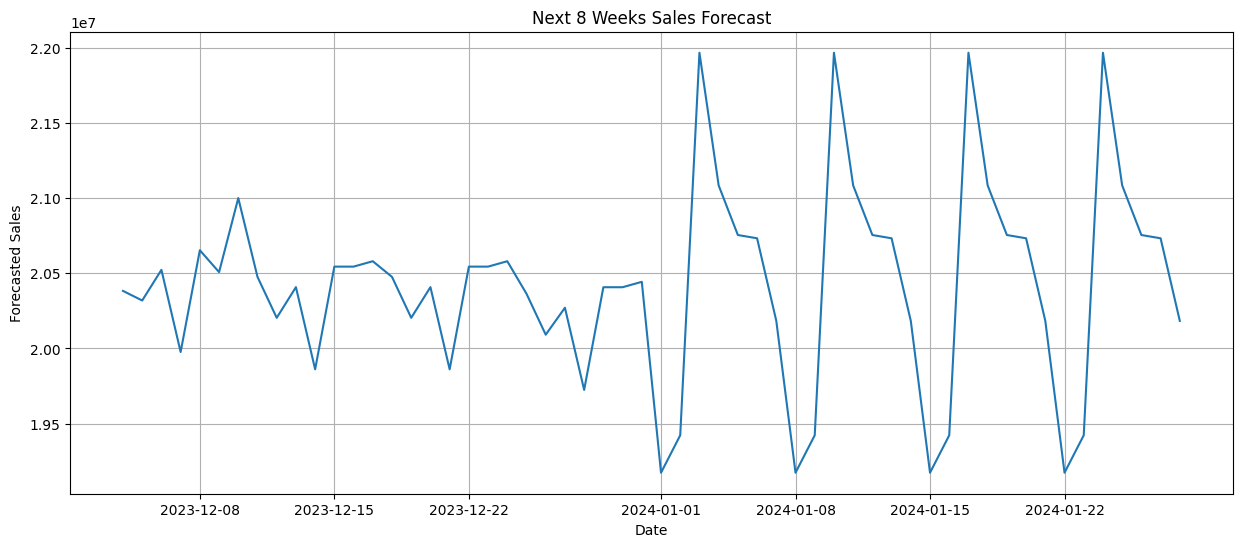

In [17]:
plt.figure(figsize=(15,6))

plt.plot(
    future_df['Date'],
    future_df['Forecasted_Sales']
)

plt.title("Next 8 Weeks Sales Forecast")

plt.xlabel("Date")

plt.ylabel("Forecasted Sales")

plt.grid(True)

plt.show()